### Employee performance analysis

In [1]:
import pandas as pd
import numpy as np

data = {
    'Employee': ['Ravi', 'Priya', 'Anil', 'Neha', 'Karan', 'Meena', 'Amit', 'Divya', 'John', 'Sana'],
    'Department': ['IT', 'HR', 'IT', 'Finance', 'IT', 'Finance', 'HR', 'IT', 'Finance', 'HR'],
    'Salary': [90000, 60000, 75000, np.nan, 30000, 85000, 45000, 99000, 67000, np.nan],
    'Experience': [5, 3, 6, 2, 1, 7, 4, 10, np.nan, 5],
    'Rating': [4.2, 3.8, 4.0, 4.5, 3.2, 4.6, np.nan, 4.9, 4.0, 3.5]
}

df = pd.DataFrame(data)


#### Data cleaning

In [4]:
df["Salary"].fillna(df["Salary"].mean(),inplace=True)
df["Experience"].fillna(df["Experience"].mean(),inplace=True)
df["Rating"].fillna(df["Rating"].mode()[0],inplace=True)

print(df)

  Employee Department   Salary  Experience  Rating
0     Ravi         IT  90000.0    5.000000     4.2
1    Priya         HR  60000.0    3.000000     3.8
2     Anil         IT  75000.0    6.000000     4.0
3     Neha    Finance  68875.0    2.000000     4.5
4    Karan         IT  30000.0    1.000000     3.2
5    Meena    Finance  85000.0    7.000000     4.6
6     Amit         HR  45000.0    4.000000     4.0
7    Divya         IT  99000.0   10.000000     4.9
8     John    Finance  67000.0    4.777778     4.0
9     Sana         HR  68875.0    5.000000     3.5


C:\Users\HP\AppData\Local\Temp\ipykernel_37944\1432153750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salary"].fillna(df["Salary"].mean(),inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_37944\1432153750.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

#### Analysis

In [18]:
filter_df=df.groupby(by="Department")["Salary"].mean().reset_index()
print(filter_df)

  Department        Salary
0    Finance  73625.000000
1         HR  57958.333333
2         IT  73500.000000


In [16]:
filter1_df=df.groupby(by="Department")["Rating"].mean().sort_values(ascending=False).reset_index()
print(filter1_df.iloc[0]["Department"])

Finance


In [10]:
def label(row):
    exp=row["Experience"]
    if exp>=7:
        return "Senior"
    elif exp>=3:
        return "Mid"
    else:
        return "Junior"

df["Seniority"]=df.apply(label,axis=1)
print(df)

  Employee Department   Salary  Experience  Rating Seniority
0     Ravi         IT  90000.0    5.000000     4.2       Mid
1    Priya         HR  60000.0    3.000000     3.8       Mid
2     Anil         IT  75000.0    6.000000     4.0       Mid
3     Neha    Finance  68875.0    2.000000     4.5    Junior
4    Karan         IT  30000.0    1.000000     3.2    Junior
5    Meena    Finance  85000.0    7.000000     4.6    Senior
6     Amit         HR  45000.0    4.000000     4.0       Mid
7    Divya         IT  99000.0   10.000000     4.9    Senior
8     John    Finance  67000.0    4.777778     4.0       Mid
9     Sana         HR  68875.0    5.000000     3.5       Mid


#### Numpy incoming :>

In [14]:
salary_arr=np.array(df["Salary"])
avg=salary_arr.mean()
std=salary_arr.std()
df["Z-Score"]=df.apply(lambda x:(x["Salary"]-avg)/std,axis=1)
print(df)

  Employee Department   Salary  Experience  Rating Seniority   Z-Score
0     Ravi         IT  90000.0    5.000000     4.2       Mid  1.081575
1    Priya         HR  60000.0    3.000000     3.8       Mid -0.454389
2     Anil         IT  75000.0    6.000000     4.0       Mid  0.313593
3     Neha    Finance  68875.0    2.000000     4.5    Junior  0.000000
4    Karan         IT  30000.0    1.000000     3.2    Junior -1.990354
5    Meena    Finance  85000.0    7.000000     4.6    Senior  0.825581
6     Amit         HR  45000.0    4.000000     4.0       Mid -1.222372
7    Divya         IT  99000.0   10.000000     4.9    Senior  1.542364
8     John    Finance  67000.0    4.777778     4.0       Mid -0.095998
9     Sana         HR  68875.0    5.000000     3.5       Mid  0.000000


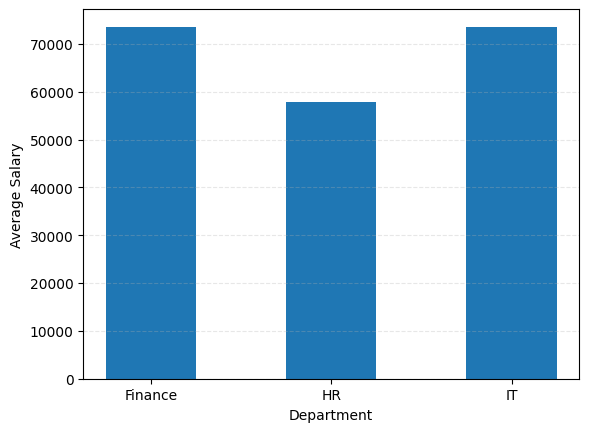

In [36]:
import matplotlib.pyplot as plt
department=np.array(filter_df["Department"])
salary=np.array(filter_df["Salary"])
plt.bar(department,salary,width=0.5)
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.grid(axis="y",ls="--",alpha=0.3)
plt.show()

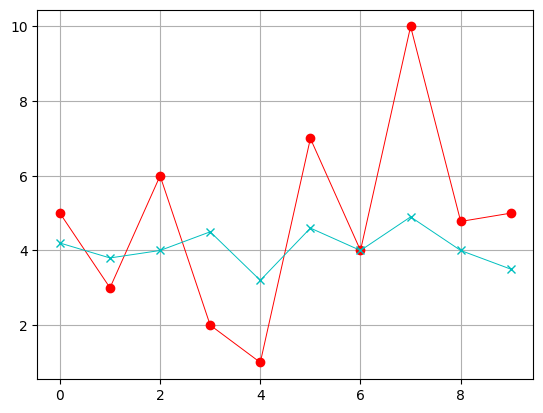

In [37]:
exp=np.array(df["Experience"])
rating=np.array(df["Rating"])
xaxis=np.arange(0,10)
plt.plot(xaxis,exp,color="r",lw=0.7,marker="o")
plt.plot(xaxis,rating,color="c",lw=0.7,marker="x")
plt.grid()
plt.show()

In [42]:
!pip install seaborn

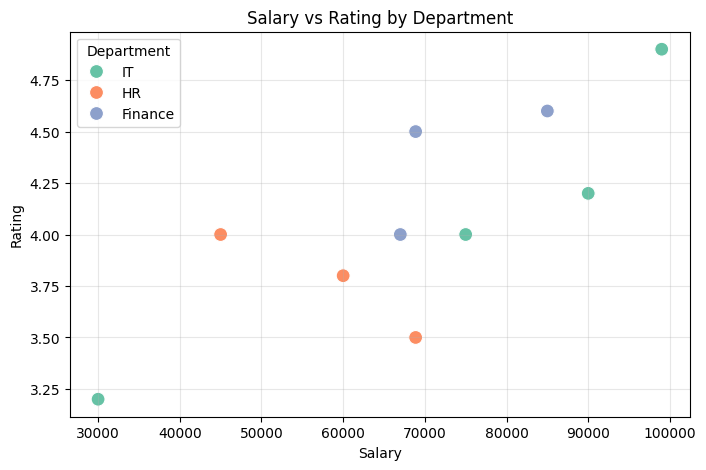

In [43]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Salary', y='Rating', hue='Department', palette='Set2', s=100)
plt.title("Salary vs Rating by Department")
plt.grid(alpha=0.3)
plt.show()


In [40]:
sorted=df.sort_values(by="Rating",ascending=False).reset_index()
print(sorted.head(5))

   index Employee Department   Salary  Experience  Rating Seniority   Z-Score
0      7    Divya         IT  99000.0        10.0     4.9    Senior  1.542364
1      5    Meena    Finance  85000.0         7.0     4.6    Senior  0.825581
2      3     Neha    Finance  68875.0         2.0     4.5    Junior  0.000000
3      0     Ravi         IT  90000.0         5.0     4.2       Mid  1.081575
4      2     Anil         IT  75000.0         6.0     4.0       Mid  0.313593
